In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [3]:
# load in data
data = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
print(data.shape)
data.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# split data into testing and training datasets
np.random.seed(42)
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

test = data[0:1000].T
Y_test = test[0] # labels of the test data
X_test = test[1:n] # test data
X_test = np.divide(X_test, 255)

train = data[1000:m].T
Y_train = train[0] # labels of the training data
X_train = train[1:n] # training data
X_train = np.divide(X_train, 255)

In [6]:
# check that dimensions are correct
X_train.shape

(784, 41000)

In [20]:
'''
Initialization for only one hidden layer

def init_params():
    W1 = np.random.randn(128, 784) * np.sqrt(2 / 784) # generates first layer weights
    b1 = np.random.rand(10, 1) - 0.5 # generates first biases from -0.5 to 0.5
    W2 = np.random.randn(10, 128) * np.sqrt(2 / 128) # generates second layer weights
    b2 = np.random.rand(10, 1) - 0.5 # generates second biases from -0.5 to 0.5
    return W1, b1, W2, b2
'''

# parameter initialization for any number of layers
def init_params(layer_sizes: list) -> tuple[list, list]:
    weights = []
    biases = []

    for i in range(len(layer_sizes) - 1):
        W = np.random.randn(
            layer_sizes[i + 1],
            layer_sizes[i]
        ) * np.sqrt(2 / layer_sizes[i])  # Kaiming initialization
        b = np.zeros((layer_sizes[i + 1], 1))

        weights.append(W)
        biases.append(b)

    return weights, biases

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

'''
Forward propagation for only one hidden layer

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2
'''

# forward propogation for any number of layers
def forward_prop(weights: list, biases: list, X):
    activations = [X]
    Zs = []
    A = X

    for i in range(len(weights) - 1):
        Z = weights[i].dot(A) + biases[i]
        A = ReLU(Z)

        Zs.append(Z)
        activations.append(A)

    # Output layer (softmax)
    Z = weights[-1] @ A + biases[-1]
    A = softmax(Z)

    Zs.append(Z)
    activations.append(A)

    return activations, Zs

# encode the labels (0-9) into a 1D vector
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max()+1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

# returns True (1) for z > 0 and False (0) when z = 0
def deriv_ReLU(Z):
    return Z > 0

'''
Back propagation for only one hidden layer

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2
'''
# back propagation for any number of layers
def back_prop(Zs: list, activations:list, weights: list, X, Y):
    
    m = Y.shape[0]
    one_hot_Y = one_hot(Y)

    # initialize derivatives
    dWs = [None] * len(weights)
    dbs = [None] * len(weights)

    # output layer gradient
    dZ = activations[-1] - one_hot_Y
    dWs[-1] = (1 / m) * dZ.dot(activations[-2].T)
    dbs[-1] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

    # Hidden layers (propagating backwards)
    for i in reversed(range(len(weights) - 1)):
        dZ = (weights[i + 1].T.dot(dZ)) * deriv_ReLU(Zs[i])
        dWs[i] = (1 / m) * dZ.dot(activations[i].T)
        dbs[i] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

    return dWs, dbs

'''
Paramter updater for only one hidden layer

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2
'''

def update_params(weights, biases, dWs, dbs, alpha):
    for i in range(len(weights)):
        weights[i] -= alpha * dWs[i]
        biases[i] -= alpha * dbs[i]
    return weights, biases

In [21]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

'''
Gradient descent for only one hidden layer

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i%10==0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2
'''

def gradient_descent(X, Y, layer_sizes, iterations, alpha):
    weights, biases = init_params(layer_sizes)
    for i in range(iterations):
        activations, Zs = forward_prop(weights, biases, X)
        dWs, dbs = back_prop(Zs, activations, weights, X, Y)
        weights, biases = update_params(weights, biases, dWs, dbs, alpha)

        if i%10==0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(activations[-1]), Y))
    return weights, biases

In [22]:
# test gradient_descent
# W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)
weights, biases = gradient_descent(X_train, Y_train, [784, 128, 64, 10], 500, 0.1)

Iteration:  0
[4 6 4 ... 4 4 9] [2 6 4 ... 2 6 0]
Accuracy:  0.09426829268292683
Iteration:  10
[2 6 4 ... 9 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.6763414634146342
Iteration:  20
[2 6 4 ... 9 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.7964878048780488
Iteration:  30
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.834
Iteration:  40
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.8536341463414634
Iteration:  50
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.8672926829268293
Iteration:  60
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.8758780487804878
Iteration:  70
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.8831951219512195
Iteration:  80
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.8894390243902439
Iteration:  90
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.8938536585365854
Iteration:  100
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.8982439024390244
Iteration:  110
[2 6 4 ... 4 6 0] [2 6 4 ... 2 6 0]
Accuracy:  0.9012926829268293
Iteration:  120
[2 6 4 ... 9 6 0] [2 6 

In [26]:
# Visualize model predictions on training data
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28,28))*255
    plt.gray()
    plt.imshow(current_image, interpolation = "nearest")
    plt.show()

# Adapted for multi-layer models
def make_predictions2(X, weights, biases):
    activations, Zs = forward_prop(weights, biases, X)
    predictions = get_predictions(activations[-1])
    return predictions

def test_prediction2(index, weights, biases):
    current_image = X_train[:, index, None]
    prediction = make_predictions2(current_image, weights, biases)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28,28))*255
    plt.gray()
    plt.imshow(current_image, interpolation = "nearest")
    plt.show()

Prediction:  [2]
Label:  2


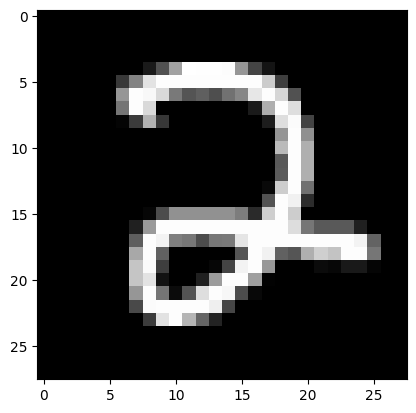

In [32]:
# Verify correctness of individual predictions
# test_prediction(0, W1, b1, W2, b2)
test_prediction2(0, weights, biases)

In [33]:
# Run model on test data (for one layer model)
test_predictions = make_predictions(X_test, W1, b1, W2, b2)
get_accuracy(test_predictions, Y_test)

NameError: name 'W1' is not defined

In [34]:
# Run model on test data (for multi-layer model)
test_predictions = make_predictions2(X_test, weights, biases)
get_accuracy(test_predictions, Y_test)

[8 1 9 9 8 6 2 2 7 1 6 3 1 2 7 4 3 3 6 4 8 5 2 6 0 0 0 8 6 3 6 6 1 2 8 6 7
 3 6 1 9 7 9 6 8 3 4 2 7 8 4 3 3 7 1 2 6 2 9 6 4 0 4 8 6 5 4 3 9 3 9 4 2 8
 1 6 3 7 0 3 1 7 6 7 6 1 9 5 3 6 9 3 7 6 6 5 2 9 3 5 4 6 0 4 1 1 1 6 8 9 1
 1 4 7 1 0 3 6 9 4 1 3 7 3 9 6 5 7 1 0 6 5 6 4 2 0 9 9 9 4 2 3 6 4 0 9 9 1
 7 7 1 6 8 1 7 6 6 5 7 9 9 0 7 9 9 1 3 6 5 8 7 1 6 7 0 9 3 0 8 6 0 1 9 9 2
 3 7 2 6 6 4 8 9 6 0 3 4 5 5 6 3 1 5 3 7 9 9 0 7 4 7 5 1 1 0 2 5 3 8 1 3 9
 3 6 7 3 1 3 4 4 0 2 7 1 4 8 1 0 5 3 9 8 7 6 5 1 0 5 7 9 7 1 7 7 4 2 2 3 4
 5 2 6 4 1 8 8 5 5 5 2 8 6 6 6 1 0 6 3 1 9 9 0 8 3 9 7 7 2 3 1 8 2 6 1 5 1
 0 0 5 2 5 6 9 6 7 1 1 3 7 3 2 5 1 8 3 1 2 1 2 9 7 2 7 8 4 7 0 3 9 4 0 1 6
 9 4 6 2 3 3 0 3 3 0 7 0 0 6 8 2 4 7 1 8 1 0 5 6 1 5 7 3 9 9 3 3 3 8 4 2 1
 0 7 7 4 0 2 0 7 0 8 7 0 0 4 8 8 7 2 1 7 0 7 6 1 4 9 6 2 1 2 4 6 1 1 6 6 0
 2 2 9 3 1 8 4 1 2 3 9 7 4 1 7 0 9 0 3 2 3 0 7 4 8 6 8 4 1 4 5 8 4 0 9 6 6
 3 7 3 9 4 5 5 3 1 8 7 7 4 8 4 8 6 3 6 0 6 8 8 8 4 0 0 7 8 9 6 7 3 1 5 8 1
 3 0 1 3 1 1 6 6 2 1 7 2 

np.float64(0.947)